In [1]:
from src.models import *
import src.utils as utils
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import mlflow

import pickle

from mlflow.tracking import MlflowClient

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
def get_data():
    global label_map
    data_dir = r'F:\thesis\Articles\2nd\code\Data'
    file_name = 'input.pkl'
    file_name_label = 'output.pkl'
    file_path = os.path.join(data_dir, file_name)
    file_path_label = os.path.join(data_dir, file_name_label)

    data = utils.read_pkl(file_path)
    label = utils.read_pkl(file_path_label)

    label_encoded, label_map = utils.label_encoder(label)

    X_train, X_test, y_train, y_test = train_test_split(
        data,
        label_encoded,
        test_size = 0.2,
        random_state = 69,
        shuffle = True,
    )

    (X_train_scaled, X_test_scaled),scaler_list = utils.scale_it(X_train, X_test)

    X_train_scaled_tensor, y_train_tensor = utils.tensor_it(X_train_scaled,y_train)
    X_test_scaled_tensor, y_test_tensor = utils.tensor_it(X_test_scaled,y_test)

    return X_train_scaled_tensor, y_train_tensor, X_test_scaled_tensor, y_test_tensor, label_map


In [3]:

art_dir2 = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\994478961421787748\5945e3b605184dd4866fcccf6edc6ace\artifacts'
art_dir = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\623922822895938578\26f61da787ea448cb55e49f781245ffe\artifacts'
weight_dir = os.path.join(art_dir,'test_weight.pth')
weight_dir2 = os.path.join(art_dir2,'test_weight.pth')

X, y, X_t, y_t, lm = get_data()

model = utils.load_model(Model2(26), weight_dir)
model2 = utils.load_model(Network(26), weight_dir2)

y_hat = utils.model_forward(model, X_t, y_t)
y_hat2 = utils.model_forward(model2, X_t, y_t)

pred_dic2 = utils.pred_mat(X_t, y_t, y_hat2, list(lm.values()))

UnboundLocalError: cannot access local variable 'predicted' where it is not associated with a value

In [6]:
mat01=pred_dic2['0_1']
mat10=pred_dic2['1_0']
mat11 =pred_dic2['1_1']
mat00 = pred_dic2['0_0']

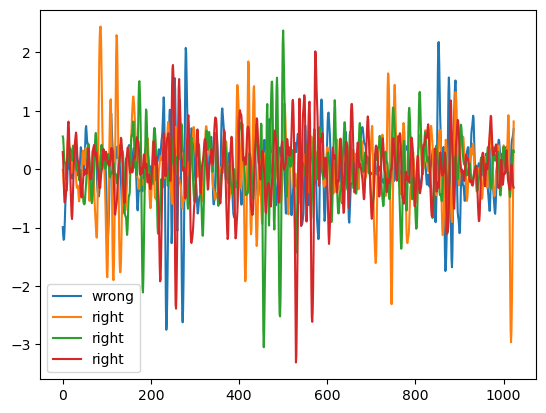

In [ ]:
plt.plot(mat10[0,:,0
], label='wrong')
plt.plot(mat11[1,:,0
], label='right')
plt.plot(mat11[2,:,0
], label='right')
plt.plot(mat11[3,:,0
], label='right')
plt.legend()

In [4]:
art_dir2 = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\994478961421787748\5945e3b605184dd4866fcccf6edc6ace\artifacts'
art_dir = r'F:\thesis\Articles\2nd\mlruns-20250726T033440Z-1-001\mlruns\623922822895938578\26f61da787ea448cb55e49f781245ffe\artifacts'
weight_dir = os.path.join(art_dir,'test_weight.pth')
weight_dir2 = os.path.join(art_dir2,'test_weight.pth')

model2 = utils.load_model(Network(26), weight_dir2)
label_coder = lambda x: torch.nn.functional.one_hot(x,num_classes=26)

X, y, X_t, y_t, lm = get_data()

In [7]:
features_train = torch.zeros(len(X),5,1088-64+26)
features_test = torch.zeros(len(X_t),5,1088-64+26)
model2.eval()
with torch.no_grad():
    for i, input_train in enumerate(X):

        output, embed = model2(input_train)
        embed = embed[:,:-64] # Delete classifier features (keep FE features)
        output,_ = torch.max(output, 1)
        output = output.long()
        y_code = label_coder(output)
        y_code[2,:]  = 0

        features_train[i] = torch.concat([y_code, embed], dim=1)
    for i, input_train in enumerate(X_t):

        output, embed = model2(input_train)
        embed = embed[:,:-64] # Delete classifier features (keep FE features)
        output,_ = torch.max(output, 1)
        output = output.long()
        y_code = label_coder(output)
        y_code[2,:]  = 0

        features_test[i] = torch.concat([y_code, embed], dim=1)

In [6]:
y_code.shape

torch.Size([5, 26])

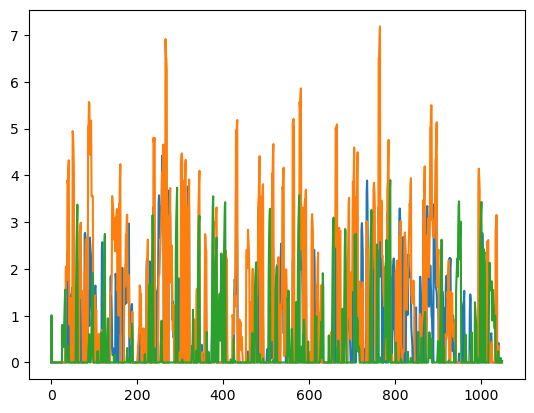

In [40]:
plt.plot(features_train[0,2,:].cpu().numpy())
plt.plot(features_train[50,2,:].cpu().numpy())
plt.plot(features_train[150,2,:].cpu().numpy())
# plt.xlim((1114-200, 1114))

In [8]:
with open('features_train.pkl', 'wb') as file:
    pickle.dump(features_train, file)
with open('features_test.pkl', 'wb') as file:
    pickle.dump(features_test, file)
with open('y_train.pkl', 'wb') as file:
    pickle.dump(y, file)
with open('y_test.pkl', 'wb') as file:
    pickle.dump(y_t, file)

train Aux model (only mode)

In [5]:
X_train_scaled_tensor = utils.read_pkl('Data/features_train.pkl')
X_test_scaled_tensor = utils.read_pkl('Data/features_test.pkl')
y_train_tensor = utils.read_pkl('Data/y_train.pkl')
y_test_tensor = utils.read_pkl('Data/y_test.pkl')

train_loader = utils.make_loader(X_train_scaled_tensor,y_train_tensor, 128)
test_loader = utils.make_loader(X_test_scaled_tensor,y_test_tensor, 128)

if mlflow.active_run():
    mlflow.end_run()

experiment_name = 'justAuxiliary'
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    mlflow.create_experiment(experiment_name)
mlflow.set_experiment(experiment_name)

mlflow.start_run()
mlflow.log_param('label map',lm)
data = X_train_scaled_tensor
mlflow.log_param('data_shape', data.shape)
mlflow.set_tag('Describe', 'All features (CNN & MLP)')

# model = models.Model2(26).to(device)
# model = models.Network(26).to(device)
# model = Auxilixary(26).to(device)
model = TransformerClassifier(input_dim=1050*5, d_model=1050*5)
model.save_path = r'F:\thesis\Articles\2nd\code\temp\test_weight.pth'
model.patience = 50
model.best_acc = -100
model.e_ratio = 1000

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
a = utils.train_classifier(
    model,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    epochs=300,
    early_stopping='val_loss',
    alpha = 0.5,
    mode = 'justaux'
)


# try:
train_cr = utils.show_report(model, X_train_scaled_tensor, y_train_tensor, list(label_map.keys()))
test_cr = utils.show_report(model, X_test_scaled_tensor, y_test_tensor, list(label_map.keys()), split='Test')
train_cm = utils.calc_cm(model, X_train_scaled_tensor, y_train_tensor)
test_cm = utils.calc_cm(model, X_test_scaled_tensor, y_test_tensor)
# except ValueError:
#     train_cr = utils.show_report(model, X_train_scaled_tensor, y_train_tensor[:,2], list(label_map.keys()))
#     test_cr = utils.show_report(model, X_test_scaled_tensor, y_test_tensor[:,2], list(label_map.keys()), split='Test')
#     train_cm = utils.calc_cm(model, X_train_scaled_tensor, y_train_tensor[:,2])
#     test_cm = utils.calc_cm(model, X_test_scaled_tensor, y_test_tensor[:,2])

utils.save_cm(train_cm, list(label_map.keys()))
utils.save_cm(test_cm, list(label_map.keys()), split="Test")



with open(r'F:\thesis\Articles\2nd\code\temp\train_cr.txt', 'w', encoding='utf-8') as f:
    f.write(train_cr)
with open(r'F:\thesis\Articles\2nd\code\temp\test_cr.txt', 'w', encoding='utf-8') as f:
    f.write(train_cr)

mlflow.log_artifacts(r'F:\thesis\Articles\2nd\code\temp')
mlflow.end_run()

AssertionError: embed_dim must be divisible by num_heads